In [ ]:
from alc import *
from imports import *
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import os
import matplotlib.pyplot as plt

from labos.Labo1 import transpuesta
from labos.Labo5 import calculaQR
from labos.Labo8 import svd_reducida


ModuleNotFoundError: No module named 'seaborn'

In [28]:
actualPath = os.getcwd()
basePath = os.path.join(actualPath, "cats_and_dogs")
Xt, Yt, Xv, Yv = cargarDataset(basePath)

Divido los datos en 4-set tal que cada set tenga la misma cantidad de datos de perros como de gatos

In [27]:
import random
def random_k_samples(emb, res, k):
    X, Y = [], []
    aux = transpuesta(emb)
    idx = random.sample(range(emb.shape[1]), k) # Garantiza no repetidos
    for r in idx:
        X.append(aux[r])
        Y.append(res[r])
    return transpuesta(np.array(X)), np.array(Y)
        
X,Y = random_k_samples(Xt, Yt,10)
print(X.shape)
print(Y)


(1536, 10)
[[1 0]
 [1 0]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [0 1]]


## Cholesky

In [ ]:
W = pinvEcuacionesNormales(Xt,transpuesta(Yt))
r = transpuesta(matmulti(W, X))
print(r)

## svd 

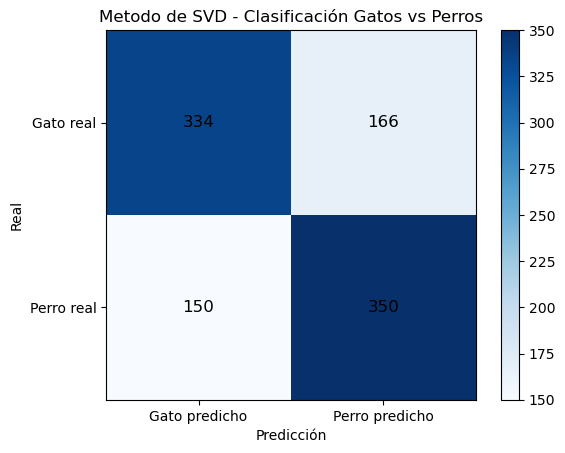

In [ ]:
s, v, d = svd_reducida(X)
W  = pinvSVD(s,v,d,Y)
r = transpuesta(matmulti(W, X))


## QR

In [ ]:
# HouseHolder
Q,R = calculaQR(transpuesta(Xt))
W = pinvHouseHolder(Q,R,Yt)
r = transpuesta(matmulti(W, X))
print(r)

KeyboardInterrupt: 

In [ ]:
Q,R = calculaQR(transpuesta(Xt),'GS')
W = pinvGramSchmidt(Q,R,Yt)
r = transpuesta(matmulti(W, X))
print(r)

## Analisis

### Matriz de confusion de metodos

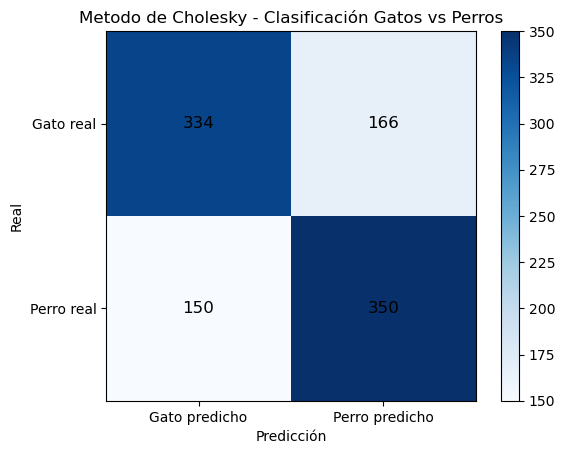

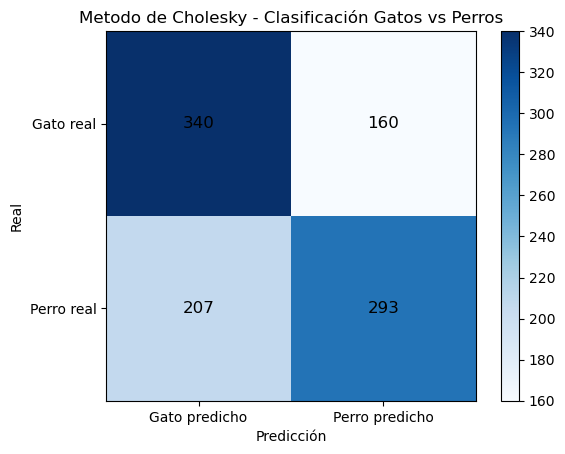

In [49]:
from sklearn.metrics import confusion_matrix

# Codigo de ploteo
W_SVD= np.load("../W_svd.npy")
W_GS = np.load("../W_e_primitivas.npy")
# W_CHOLESKY =np.load("../W_e_primitivas.npy")
# W_HH =np.load("../W_e_primitivas.npy")
        
r_SVD = transpuesta( W_SVD @ Xv)
r_GS = transpuesta( W_GS @ Xv)
#Agregar las 2 W faltantes

# Lista para procesar cada r de los metodos para así crear la matriz de confusion
lista_r = list()
lista_r.append(r_SVD)
lista_r.append(r_GS)

#Listas para luego usar en la tabla de comparativa
aciertoGatos = list()
aciertoPerros = list()
precisionModelo = list()

# Convertir las predicciones a clases: elegimos el índice del valor máximo
# (por ejemplo [0.8, 0.2] → gato / [0.3, 0.7] → perro)
for r in lista_r:
    predicciones = np.argmax(r, axis=1)
    etiquetas_reales = np.argmax(Yv, axis=1)


    # Crear matriz de confusión
    
    matriz_conf = confusion_matrix(etiquetas_reales, predicciones)

    #Agrego aciertos para luego crear la tabla
    aciertoGatos.append(matriz_conf[0,0]/5) 
    aciertoPerros.append(matriz_conf[1,1]/5)
    precisionModelo.append((matriz_conf[0,0] + matriz_conf[1,1])/10)


    plt.imshow(matriz_conf, cmap='Blues')
    plt.colorbar()

    # Mostrar los valores dentro de cada celda
    for i in range(matriz_conf.shape[0]):
        for j in range(matriz_conf.shape[1]):
            plt.text(j, i, matriz_conf[i, j],
                     ha='center', va='center', color='black', fontsize=12)


    # Etiquetas de ejes
    plt.xticks([0, 1], ['Gato predicho', 'Perro predicho'])
    plt.yticks([0, 1], ['Gato real', 'Perro real'])

    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.title('Metodo de Cholesky - Clasificación Gatos vs Perros')

    plt.show()


### Tabla comparativa de resultados de cada metodologia

In [52]:
import pandas as pd


data = {
    "Tasa de aciertos con gatos": aciertoGatos,
    "Tasa de acierto con perros": aciertoPerros,
    "Tasa de acierto total": precisionModelo
}

metodos = ["Metodo descomposicion SVD", "Metodo de Cholesky"]

df = pd.DataFrame(data, index=metodos)

print(df)

                           Tasa de aciertos con gatos  \
Metodo descomposicion SVD                        66.8   
Metodo de Cholesky                               68.0   

                           Tasa de acierto con perros  Tasa de acierto total  
Metodo descomposicion SVD                        70.0                   68.4  
Metodo de Cholesky                               58.6                   63.3  


## Sintesis Final

Al haber finalizado nuestras experimentaciones con las múltiples metodologías (SVD, Householder, Gram-Schmidt y Cholesky) y comparado los resultados obtenidos en cada uno de los entrenamientos, vamos a analizar cuáles son los más adecuados usando como parametros de evaluacion: La complejidad, la precision de aciertos y el equilibrio de las predicciones.
Para ello, vamos a ir desarrollando método por metodo describiendo su comportamiento de forma individual para luego hacer una puesta en comun.
Nuestro entrenamiento fue realizado utilizando 2000 imagenes de perros y gatos , y las pruebas finales fueron hechas sobre 1000 imagenes de prueba donde 500 de ellas son gatos y otras 500 son perros.

## Resultados

El método de descomposición de valores singulares obtuvo una tasa de aciertos (con 500 pruebas por animal) de gatos de 66,8 % y de perros de 70%, y una precisión total de 68,4%. Se puede observar que la tasa de aciertos entre gatos y perros es similar lo que es una buena señal ya que nos muestra una matriz de entrenamiento que conserva equilibrio en los resultados. Es decir, no existen sesgos.

Con el método de Cholesky, el acierto de gatos fue de 68% , de perros 58.6%, y un acierto total de 63,3%. En este caso hay una diferencia mayor entre las dos clases, teniendo una tendencia a pronosticar gatos lo cual nos hace preguntarnos si la alta tasa de aciertos sobre gatos se debe a un buen entrenamiento o a esta tendencia.

Con respecto al metodo de Gram schmidt, el acierto de gatos fue de 68% , de perros 58.6%, y un acierto total de 63,3%. Podemos observar que los resultados en la prediccion son identicos al metodo de Cholesky.

## Analisis de complejidad
 
Cholesky O(n³)
GS O()
SVD O()



## Conclusion
Nuestra conclusion como grupo es que el modelo entrenado con la descomposicion de valores singulares es la que domina en torno a todas las metodologias. Esta descomposion nos muestra un balance entre efectividad y equilibrio de resultados. 


    